In [26]:
from google.colab import files
upload = files.upload()


Saving uber_ride_bookings.csv to uber_ride_bookings (1).csv


In [27]:
import pandas as pd

data = pd.read_csv("uber_ride_bookings.csv")
data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,23-03-2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29-11-2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,23-08-2024,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,21-10-2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,16-09-2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [28]:
data.isnull().sum()
(data.isnull().sum() / len(data)) * 100


,0
Date,0.0
Time,0.0
Booking ID,0.0
Booking Status,0.0
Customer ID,0.0
Vehicle Type,0.0
Pickup Location,0.0
Drop Location,0.0
Avg VTAT,7.0
Avg CTAT,32.0


In [29]:
# Drop useless columns
# Clean column names first to handle potential leading/trailing spaces or invisible characters
data.columns = data.columns.str.strip()

columns_to_drop = [
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason'
]

# Drop columns that exist in the DataFrame
# Use errors='ignore' to prevent error if a column is already missing (though cleaning should help)
data = data.drop(columns=columns_to_drop, errors='ignore')

data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,23-03-2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29-11-2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,NaN,NaN,UPI
2,23-08-2024,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card
3,21-10-2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI
4,16-09-2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI


In [30]:
# Fill numerical columns
num_cols = [
    'Avg VTAT', 'Avg CTAT',
    'Booking Value', 'Ride Distance',
    'Driver Ratings', 'Customer Rating'
]

for col in num_cols:
  data[col] = data[col].fillna(data[col].median())

data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,23-03-2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,414.0,23.72,4.3,4.5,NaN
1,29-11-2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237.0,5.73,4.3,4.5,UPI
2,23-08-2024,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627.0,13.58,4.9,4.9,Debit Card
3,21-10-2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416.0,34.02,4.6,5.0,UPI
4,16-09-2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI


In [31]:
data.isnull().sum()


,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0


In [32]:
data['Booking Status'].value_counts()


,count
Booking Status,
Completed,93000
Cancelled by Driver,27000
No Driver Found,10500
Cancelled by Customer,10500
Incomplete,9000


In [33]:
# Change date format
data["Date"] = pd.to_datetime(data['Date'], format='mixed') # mixed (or) "%dd-%mm-%yyyy"
# Sort by Date
data = data.sort_values(by= "Date")

data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
44979,2024-01-01,14:08:23,"""CNR3175918""",Completed,"""CID3171551""",Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,176.0,45.61,4.5,3.8,Credit Card
101462,2024-01-01,06:51:01,"""CNR7377162""",Completed,"""CID7227079""",Go Mini,Bhiwadi,Ardee City,6.5,43.4,563.0,40.13,4.6,4.9,UPI
14378,2024-01-01,07:26:17,"""CNR6813909""",Completed,"""CID4108516""",Auto,Ghitorni,South Extension,7.7,43.4,523.0,22.13,4.6,3.9,UPI
141135,2024-01-01,02:56:49,"""CNR9519641""",Cancelled by Driver,"""CID1177393""",Bike,Green Park,Adarsh Nagar,7.7,28.8,414.0,23.72,4.3,4.5,NaN
70228,2024-01-01,14:20:52,"""CNR9832336""",Cancelled by Driver,"""CID8077824""",Premier Sedan,Saket A Block,AIIMS,4.9,28.8,414.0,23.72,4.3,4.5,NaN


In [34]:
data[['Booking ID', 'Customer ID']] = data[['Booking ID', 'Customer ID']].replace('"', '', regex=True)
data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,176.0,45.61,4.5,3.8,Credit Card
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,563.0,40.13,4.6,4.9,UPI
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,523.0,22.13,4.6,3.9,UPI
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,414.0,23.72,4.3,4.5,NaN
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,414.0,23.72,4.3,4.5,NaN


In [35]:
# Change column datatype (int)
int_col = [
    'Avg VTAT', 'Avg CTAT',
    'Booking Value', 'Ride Distance',
    'Driver Ratings', 'Customer Rating'
]

for col in int_col:
  data[col] = data[col].astype("float")

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 44979 to 100761
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date             150000 non-null  datetime64[ns]
 1   Time             150000 non-null  object        
 2   Booking ID       150000 non-null  object        
 3   Booking Status   150000 non-null  object        
 4   Customer ID      150000 non-null  object        
 5   Vehicle Type     150000 non-null  object        
 6   Pickup Location  150000 non-null  object        
 7   Drop Location    150000 non-null  object        
 8   Avg VTAT         150000 non-null  float64       
 9   Avg CTAT         150000 non-null  float64       
 10  Booking Value    150000 non-null  float64       
 11  Ride Distance    150000 non-null  float64       
 12  Driver Ratings   150000 non-null  float64       
 13  Customer Rating  150000 non-null  float64       
 14  Payment Method   1020

In [36]:
# Extract Hour (for peak analysis)
data['Hour'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.hour
data

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,176.0,45.61,4.5,3.8,Credit Card,14
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,563.0,40.13,4.6,4.9,UPI,6
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,523.0,22.13,4.6,3.9,UPI,7
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,414.0,23.72,4.3,4.5,NaN,2
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,414.0,23.72,4.3,4.5,NaN,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140803,2024-12-30,09:39:38,CNR8170225,Cancelled by Driver,CID9139230,Go Mini,Janakpuri,Sadar Bazar Gurgaon,3.7,28.8,414.0,23.72,4.3,4.5,NaN,9
131019,2024-12-30,20:24:50,CNR4043886,Completed,CID1191615,Premier Sedan,Qutub Minar,Seelampur,8.9,37.7,374.0,34.10,5.0,3.1,Credit Card,20
30001,2024-12-30,15:45:02,CNR9796253,Completed,CID9574975,Go Sedan,DLF Phase 3,Chandni Chowk,10.5,40.4,98.0,34.77,4.1,4.2,Cash,15
26440,2024-12-30,04:22:08,CNR7390826,Completed,CID6804810,Auto,Anand Vihar,Patel Chowk,10.8,44.8,760.0,9.80,4.6,4.3,Debit Card,4


In [37]:
# Extract Day and Month
data['Day'] = data['Date'].dt.day_name()
data['Month'] = data['Date'].dt.month_name()
data

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Hour,Day,Month
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,176.0,45.61,4.5,3.8,Credit Card,14,Monday,January
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,563.0,40.13,4.6,4.9,UPI,6,Monday,January
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,523.0,22.13,4.6,3.9,UPI,7,Monday,January
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,414.0,23.72,4.3,4.5,NaN,2,Monday,January
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,414.0,23.72,4.3,4.5,NaN,14,Monday,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140803,2024-12-30,09:39:38,CNR8170225,Cancelled by Driver,CID9139230,Go Mini,Janakpuri,Sadar Bazar Gurgaon,3.7,28.8,414.0,23.72,4.3,4.5,NaN,9,Monday,December
131019,2024-12-30,20:24:50,CNR4043886,Completed,CID1191615,Premier Sedan,Qutub Minar,Seelampur,8.9,37.7,374.0,34.10,5.0,3.1,Credit Card,20,Monday,December
30001,2024-12-30,15:45:02,CNR9796253,Completed,CID9574975,Go Sedan,DLF Phase 3,Chandni Chowk,10.5,40.4,98.0,34.77,4.1,4.2,Cash,15,Monday,December
26440,2024-12-30,04:22:08,CNR7390826,Completed,CID6804810,Auto,Anand Vihar,Patel Chowk,10.8,44.8,760.0,9.80,4.6,4.3,Debit Card,4,Monday,December


In [38]:
# Rename Columns
data = data.rename(columns={
    'Avg VTAT': 'Vehicle Arrival Time (min)',
    'Avg CTAT': 'Customer Trip Time (min)',
    'Booking Value': "Revenue (INR)",
    'Ride Distance': 'Ride Distance (km)',
    'Driver Ratings': 'Driver Rating'
})
data

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Vehicle Arrival Time (min),Customer Trip Time (min),Revenue (INR),Ride Distance (km),Driver Rating,Customer Rating,Payment Method,Hour,Day,Month
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,176.0,45.61,4.5,3.8,Credit Card,14,Monday,January
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,563.0,40.13,4.6,4.9,UPI,6,Monday,January
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,523.0,22.13,4.6,3.9,UPI,7,Monday,January
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,414.0,23.72,4.3,4.5,NaN,2,Monday,January
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,414.0,23.72,4.3,4.5,NaN,14,Monday,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140803,2024-12-30,09:39:38,CNR8170225,Cancelled by Driver,CID9139230,Go Mini,Janakpuri,Sadar Bazar Gurgaon,3.7,28.8,414.0,23.72,4.3,4.5,NaN,9,Monday,December
131019,2024-12-30,20:24:50,CNR4043886,Completed,CID1191615,Premier Sedan,Qutub Minar,Seelampur,8.9,37.7,374.0,34.10,5.0,3.1,Credit Card,20,Monday,December
30001,2024-12-30,15:45:02,CNR9796253,Completed,CID9574975,Go Sedan,DLF Phase 3,Chandni Chowk,10.5,40.4,98.0,34.77,4.1,4.2,Cash,15,Monday,December
26440,2024-12-30,04:22:08,CNR7390826,Completed,CID6804810,Auto,Anand Vihar,Patel Chowk,10.8,44.8,760.0,9.80,4.6,4.3,Debit Card,4,Monday,December


In [39]:
# Cancellation type based on Customer, Driver

data['Cancellation Type'] = data['Booking Status'].apply(lambda x:
    'Customer' if 'Customer' in x else
    'Driver' if 'Driver' in x else
    'Ride Completed'
)
data

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Vehicle Arrival Time (min),Customer Trip Time (min),Revenue (INR),Ride Distance (km),Driver Rating,Customer Rating,Payment Method,Hour,Day,Month,Cancellation Type
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,176.0,45.61,4.5,3.8,Credit Card,14,Monday,January,Ride Completed
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,563.0,40.13,4.6,4.9,UPI,6,Monday,January,Ride Completed
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,523.0,22.13,4.6,3.9,UPI,7,Monday,January,Ride Completed
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,414.0,23.72,4.3,4.5,NaN,2,Monday,January,Driver
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,414.0,23.72,4.3,4.5,NaN,14,Monday,January,Driver
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140803,2024-12-30,09:39:38,CNR8170225,Cancelled by Driver,CID9139230,Go Mini,Janakpuri,Sadar Bazar Gurgaon,3.7,28.8,414.0,23.72,4.3,4.5,NaN,9,Monday,December,Driver
131019,2024-12-30,20:24:50,CNR4043886,Completed,CID1191615,Premier Sedan,Qutub Minar,Seelampur,8.9,37.7,374.0,34.10,5.0,3.1,Credit Card,20,Monday,December,Ride Completed
30001,2024-12-30,15:45:02,CNR9796253,Completed,CID9574975,Go Sedan,DLF Phase 3,Chandni Chowk,10.5,40.4,98.0,34.77,4.1,4.2,Cash,15,Monday,December,Ride Completed
26440,2024-12-30,04:22:08,CNR7390826,Completed,CID6804810,Auto,Anand Vihar,Patel Chowk,10.8,44.8,760.0,9.80,4.6,4.3,Debit Card,4,Monday,December,Ride Completed


In [40]:
data['Payment Method'] = data['Payment Method'].fillna(data['Payment Method'].mode()[0])
data['Payment Method'].value_counts()

,count
Payment Method,
UPI,93910
Cash,25367
Uber Wallet,12276
Credit Card,10208
Debit Card,8239


In [41]:
# Find duplicates
data.duplicated().sum()

np.int64(0)

In [42]:
data.describe()

,Date,Vehicle Arrival Time (min),Customer Trip Time (min),Revenue (INR),Ride Distance (km),Driver Rating,Customer Rating,Hour
count,150000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,2024-06-30 11:32:35.520000,8.445407,29.037753,478.121220,24.343568,4.257215,4.440842,14.034113
min,2024-01-01 00:00:00,2.000000,10.000000,50.000000,1.000000,3.000000,3.000000,0.000000
25%,2024-03-31 00:00:00,5.600000,25.000000,319.750000,17.360000,4.200000,4.300000,10.000000
50%,2024-06-30 00:00:00,8.300000,28.800000,414.000000,23.720000,4.300000,4.500000,15.000000
75%,2024-09-30 00:00:00,11.000000,32.900000,521.000000,30.650000,4.300000,4.600000,18.000000
max,2024-12-30 00:00:00,20.000000,45.000000,4277.000000,50.000000,5.000000,5.000000,23.000000
std,NaN,3.639311,7.343053,329.339976,11.554362,0.345619,0.347835,5.416906


Add New Columns

In [43]:
# Weekend vs Weekday (Day Type Column)
data["Day Type"] = data["Day"].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')
data['Day Type'].value_counts()

,count
Day Type,
Weekday,107117
Weekend,42883


In [44]:
# Distance Category column
def distance_category(distance):
  if distance < 5:
    return 'Short'
  elif distance < 15:
    return 'Medium'
  else:
    return 'Long'

data['Distance Category'] = data['Ride Distance (km)'].apply(distance_category)
data['Distance Category'].value_counts()
data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Vehicle Arrival Time (min),Customer Trip Time (min),...,Ride Distance (km),Driver Rating,Customer Rating,Payment Method,Hour,Day,Month,Cancellation Type,Day Type,Distance Category
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,...,45.61,4.5,3.8,Credit Card,14,Monday,January,Ride Completed,Weekday,Long
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,...,40.13,4.6,4.9,UPI,6,Monday,January,Ride Completed,Weekday,Long
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,...,22.13,4.6,3.9,UPI,7,Monday,January,Ride Completed,Weekday,Long
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,...,23.72,4.3,4.5,UPI,2,Monday,January,Driver,Weekday,Long
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,...,23.72,4.3,4.5,UPI,14,Monday,January,Driver,Weekday,Long


In [45]:
# Revenue Category

def revenue_category(revenue):
  if revenue < 200:
    return 'Low'
  elif revenue < 500:
    return 'Medium'
  else:
    return 'High'


data['Revenue Category'] = data['Revenue (INR)'].apply(revenue_category)
data['Revenue Category'].value_counts()

data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Vehicle Arrival Time (min),Customer Trip Time (min),...,Driver Rating,Customer Rating,Payment Method,Hour,Day,Month,Cancellation Type,Day Type,Distance Category,Revenue Category
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,...,4.5,3.8,Credit Card,14,Monday,January,Ride Completed,Weekday,Long,Low
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,...,4.6,4.9,UPI,6,Monday,January,Ride Completed,Weekday,Long,High
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,...,4.6,3.9,UPI,7,Monday,January,Ride Completed,Weekday,Long,High
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,...,4.3,4.5,UPI,2,Monday,January,Driver,Weekday,Long,Medium
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,...,4.3,4.5,UPI,14,Monday,January,Driver,Weekday,Long,Medium


In [46]:
# Rating Category

data['Driver Rating Type'] = data['Driver Rating'].apply(lambda x: 'Good' if x >= 4 else 'Bad')
data['Customer Rating Type'] = data['Customer Rating'].apply(lambda x: 'Good' if x >= 4 else 'Bad')

data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Vehicle Arrival Time (min),Customer Trip Time (min),...,Payment Method,Hour,Day,Month,Cancellation Type,Day Type,Distance Category,Revenue Category,Driver Rating Type,Customer Rating Type
44979,2024-01-01,14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,...,Credit Card,14,Monday,January,Ride Completed,Weekday,Long,Low,Good,Bad
101462,2024-01-01,06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,...,UPI,6,Monday,January,Ride Completed,Weekday,Long,High,Good,Good
14378,2024-01-01,07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,...,UPI,7,Monday,January,Ride Completed,Weekday,Long,High,Good,Bad
141135,2024-01-01,02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,...,UPI,2,Monday,January,Driver,Weekday,Long,Medium,Good,Good
70228,2024-01-01,14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,...,UPI,14,Monday,January,Driver,Weekday,Long,Medium,Good,Good


In [47]:
# Ride Quality Column (Driver Rating + Customer Rating)/2


data['Ride Quality'] = (data['Driver Rating'] + data['Customer Rating']) / 2
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 44979 to 100761
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        150000 non-null  datetime64[ns]
 1   Time                        150000 non-null  object        
 2   Booking ID                  150000 non-null  object        
 3   Booking Status              150000 non-null  object        
 4   Customer ID                 150000 non-null  object        
 5   Vehicle Type                150000 non-null  object        
 6   Pickup Location             150000 non-null  object        
 7   Drop Location               150000 non-null  object        
 8   Vehicle Arrival Time (min)  150000 non-null  float64       
 9   Customer Trip Time (min)    150000 non-null  float64       
 10  Revenue (INR)               150000 non-null  float64       
 11  Ride Distance (km)          150000 non-n

In [48]:
# Time column datatype change and format

data['Time'] = pd.to_datetime(data['Time'], format= '%H:%M:%S')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 44979 to 100761
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        150000 non-null  datetime64[ns]
 1   Time                        150000 non-null  datetime64[ns]
 2   Booking ID                  150000 non-null  object        
 3   Booking Status              150000 non-null  object        
 4   Customer ID                 150000 non-null  object        
 5   Vehicle Type                150000 non-null  object        
 6   Pickup Location             150000 non-null  object        
 7   Drop Location               150000 non-null  object        
 8   Vehicle Arrival Time (min)  150000 non-null  float64       
 9   Customer Trip Time (min)    150000 non-null  float64       
 10  Revenue (INR)               150000 non-null  float64       
 11  Ride Distance (km)          150000 non-n

In [49]:
# Convert categorical columns to category dtype

category_cols = [
    'Booking Status', 'Vehicle Type', 'Pickup Location', 'Drop Location',
    'Payment Method', 'Day', 'Month', 'Cancellation Type',
    'Day Type', 'Distance Category', 'Revenue Category',
    'Driver Rating Type', 'Customer Rating Type'
]

for col in category_cols:
  data[col] = data[col].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 44979 to 100761
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        150000 non-null  datetime64[ns]
 1   Time                        150000 non-null  datetime64[ns]
 2   Booking ID                  150000 non-null  object        
 3   Booking Status              150000 non-null  category      
 4   Customer ID                 150000 non-null  object        
 5   Vehicle Type                150000 non-null  category      
 6   Pickup Location             150000 non-null  category      
 7   Drop Location               150000 non-null  category      
 8   Vehicle Arrival Time (min)  150000 non-null  float64       
 9   Customer Trip Time (min)    150000 non-null  float64       
 10  Revenue (INR)               150000 non-null  float64       
 11  Ride Distance (km)          150000 non-n

In [50]:
# Booking Id, Customer Id dtype change in string

data[['Booking ID', 'Customer ID']] = data[['Booking ID', 'Customer ID']].astype("string")
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 44979 to 100761
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        150000 non-null  datetime64[ns]
 1   Time                        150000 non-null  datetime64[ns]
 2   Booking ID                  150000 non-null  string        
 3   Booking Status              150000 non-null  category      
 4   Customer ID                 150000 non-null  string        
 5   Vehicle Type                150000 non-null  category      
 6   Pickup Location             150000 non-null  category      
 7   Drop Location               150000 non-null  category      
 8   Vehicle Arrival Time (min)  150000 non-null  float64       
 9   Customer Trip Time (min)    150000 non-null  float64       
 10  Revenue (INR)               150000 non-null  float64       
 11  Ride Distance (km)          150000 non-n

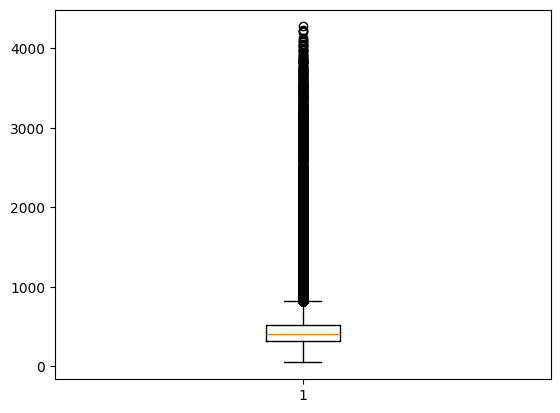

In [59]:
import matplotlib.pyplot as plt

plt.boxplot(data['Revenue (INR)'])
plt.show()


In [61]:
# High value ride some rides are more amount that was reasonable in India.
# Ex:Max Revenue ≈ ₹4277, Max Distance ≈ 50 km
data['High Value Ride'] = data['Revenue (INR)'].apply(lambda x: 'Yes' if x > 1000 else 'No')
data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Vehicle Arrival Time (min),Customer Trip Time (min),...,Day,Month,Cancellation Type,Day Type,Distance Category,Revenue Category,Driver Rating Type,Customer Rating Type,Ride Quality,High Value Ride
44979,2024-01-01,1900-01-01 14:08:23,CNR3175918,Completed,CID3171551,Premier Sedan,Udyog Vihar,MG Road,13.6,28.9,...,Monday,January,Ride Completed,Weekday,Long,Low,Good,Bad,4.15,No
101462,2024-01-01,1900-01-01 06:51:01,CNR7377162,Completed,CID7227079,Go Mini,Bhiwadi,Ardee City,6.5,43.4,...,Monday,January,Ride Completed,Weekday,Long,High,Good,Good,4.75,No
14378,2024-01-01,1900-01-01 07:26:17,CNR6813909,Completed,CID4108516,Auto,Ghitorni,South Extension,7.7,43.4,...,Monday,January,Ride Completed,Weekday,Long,High,Good,Bad,4.25,No
141135,2024-01-01,1900-01-01 02:56:49,CNR9519641,Cancelled by Driver,CID1177393,Bike,Green Park,Adarsh Nagar,7.7,28.8,...,Monday,January,Driver,Weekday,Long,Medium,Good,Good,4.40,No
70228,2024-01-01,1900-01-01 14:20:52,CNR9832336,Cancelled by Driver,CID8077824,Premier Sedan,Saket A Block,AIIMS,4.9,28.8,...,Monday,January,Driver,Weekday,Long,Medium,Good,Good,4.40,No


In [62]:
# Save the file
data.to_csv('Uber_cleaned_dataset.csv', index= False)

# Download csv file
files.download('Uber_cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>